# Exploratory Data Analysis (EDA) on Superstore Dataset

**Course:** Applied Machine Learning Lab  

## Introduction

Exploratory Data Analysis (**EDA**) is an important step before applying any machine learning model.  
It helps in understanding the **structure, patterns, and quality** of the dataset.

In this lab, we analyze the **Superstore dataset**, which contains retail sales data including customers, products, sales, profit, and shipping details.

EDA helps in:
- Detecting **missing values**
- Understanding **distributions**
- Finding **relationships between variables**
- Extracting useful **business insights**

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading Dataset

The dataset is loaded using **Pandas**, and initial rows are checked to understand its structure.

In [2]:
df = pd.read_csv("Superstore.csv")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Exercises

In [4]:
df.shape

(9994, 21)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [6]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

## 1. Sub-Category with Highest Sales

To solve this, the total sales for each sub-category are calculated first.  
Instead of writing everything in one line, the process is broken into steps so it is easier to understand.

This approach helps in clearly identifying which sub-category contributes the **maximum sales**.

In [7]:
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head()

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Sales, dtype: float64

The result shows which sub-category generates the highest sales.  
This information is useful for businesses to focus more on **high-performing products** and increase overall revenue.

In [8]:
df.groupby('Sub-Category')['Sales'].sum()

Sub-Category
Accessories    167380.3180
Appliances     107532.1610
Art             27118.7920
Binders        203412.7330
Bookcases      114879.9963
Chairs         328449.1030
Copiers        149528.0300
Envelopes       16476.4020
Fasteners        3024.2800
Furnishings     91705.1640
Labels          12486.3120
Machines       189238.6310
Paper           78479.2060
Phones         330007.0540
Storage        223843.6080
Supplies        46673.5380
Tables         206965.5320
Name: Sales, dtype: float64

In [9]:
sales_by_subcategory = df.groupby('Sub-Category')['Sales'].sum()

top_subcategory = sales_by_subcategory.idxmax()
highest_sales_value = sales_by_subcategory.max()

print(f"The sub-category with the highest sales is {top_subcategory} with ${highest_sales_value:,.2f}")

The sub-category with the highest sales is Phones with $330,007.05


## 2. Sub-Category with Lowest Profit

Here, the goal is to find which sub-category is performing poorly in terms of profit.

The total profit for each sub-category is calculated first, and then the one with the **lowest profit** is identified.

In [10]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum()

lowest_profit_subcat = subcat_profit.idxmin()
lowest_profit_value = subcat_profit.min()

print(f"The sub-category with the lowest profit is: {lowest_profit_subcat}")
print(f"Total Profit: ${lowest_profit_value:,.2f}")

The sub-category with the lowest profit is: Tables
Total Profit: $-17,725.48


The result highlights the sub-category that is contributing the least profit or possibly generating losses.

This insight can help businesses take actions such as:
- reviewing pricing strategies  
- reducing discounts  
- or improving product quality

## 3. Total Sales by Product Category

This visualization shows how total sales are distributed across different product categories.

Bar charts are useful for comparing **categorical data** clearly.

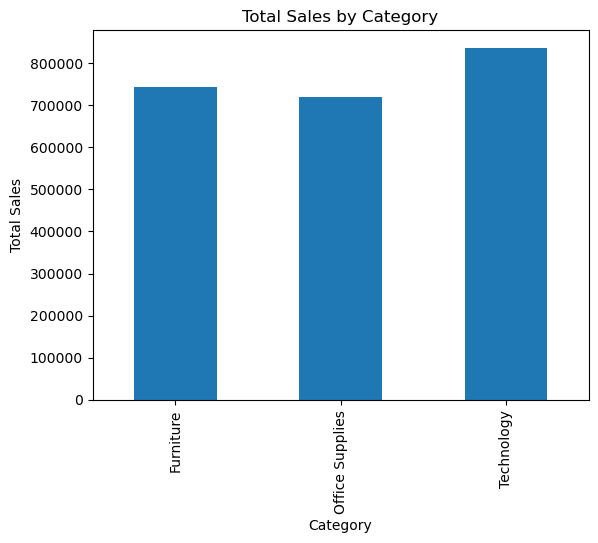

In [11]:
category_sales = df.groupby("Category")["Sales"].sum()

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

## 4. Total Profit by Region

This plot helps in identifying which region is contributing the most to overall profit.

Such analysis is useful for understanding **regional performance**.

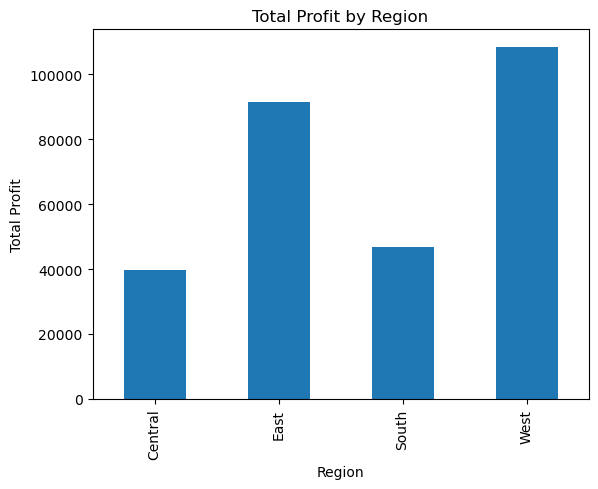

In [12]:
region_profit = df.groupby("Region")["Profit"].sum()

region_profit.plot(kind="bar")

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

## 5. Average Discount Across Categories

Discounts can significantly impact profit.  
This analysis compares the **average discount** offered in each category.

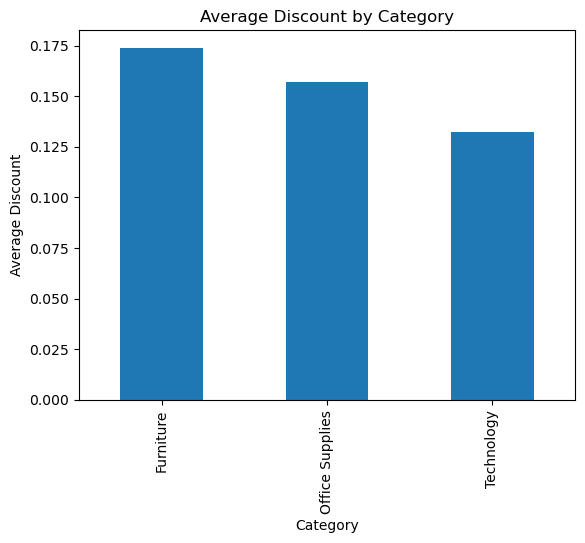

In [13]:
avg_discount = df.groupby("Category")["Discount"].mean()

avg_discount.plot(kind="bar")

plt.title("Average Discount by Category")
plt.xlabel("Category")
plt.ylabel("Average Discount")

plt.show()

In [14]:
df.groupby("Category")["Discount"].mean()

Category
Furniture          0.173923
Office Supplies    0.157285
Technology         0.132323
Name: Discount, dtype: float64

## 6. Relationship Between Discount and Profit

This scatter plot helps to understand how discount affects profit.

It is useful to check whether increasing discounts leads to higher or lower profit.

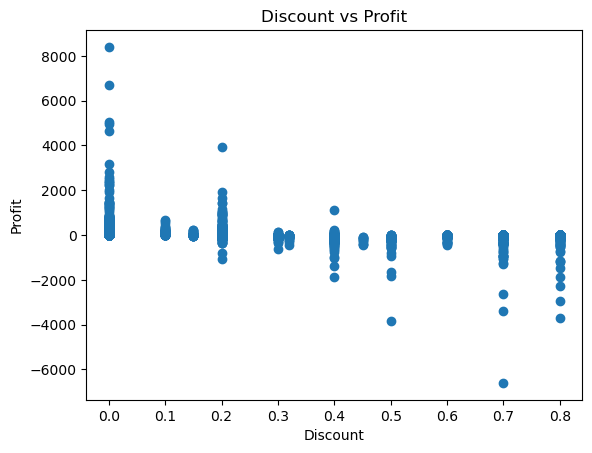

In [15]:
plt.scatter(df["Discount"], df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

In [16]:
df[["Profit","Discount"]].corr()

,Profit,Discount
Profit,1.000000,-0.219487
Discount,-0.219487,1.000000


## 7. Top Five States with Highest Sales

This step identifies the top-performing states based on total sales.

Sorting the values makes it easier to find the **highest contributors**.

In [17]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(5)

print(top_states)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


## 8. Cities Generating Highest Profit

This analysis helps identify which cities are generating the most profit.

Such insights can help businesses focus on **high-performing locations**.

In [18]:
top_cities = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(5)

print(top_cities)

City
New York City    62036.9837
Los Angeles      30440.7579
Seattle          29156.0967
San Francisco    17507.3854
Detroit          13181.7908
Name: Profit, dtype: float64


## 9. Quantity Sold by Category

This visualization shows how many items are sold in each category.

It helps understand **product demand** across categories.

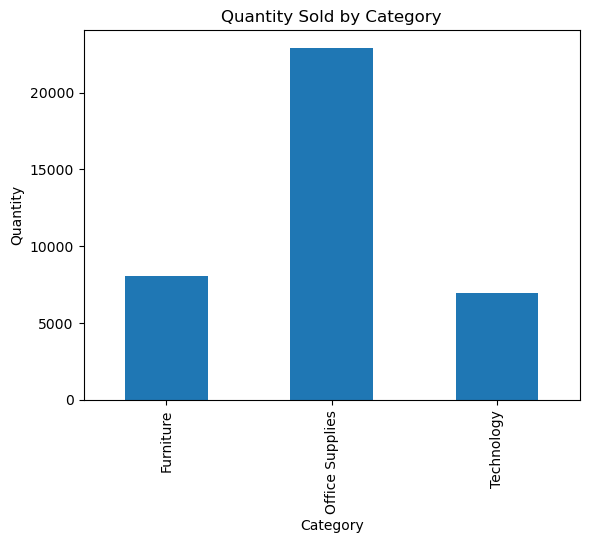

In [19]:
quantity = df.groupby("Category")["Quantity"].sum()

quantity.plot(kind="bar")

plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")

plt.show()

## 10. Sales Trend Over Time

To analyze how sales change over time, the Order Date column is converted into datetime format.

This helps in identifying **trends and patterns** over different time periods.

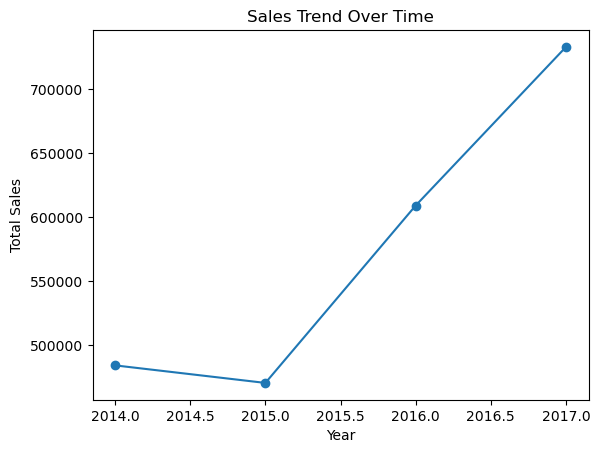

In [20]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

sales_trend = df.groupby(df["Order Date"].dt.year)["Sales"].sum()

sales_trend.plot(kind="line", marker="o")

plt.title("Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.show()

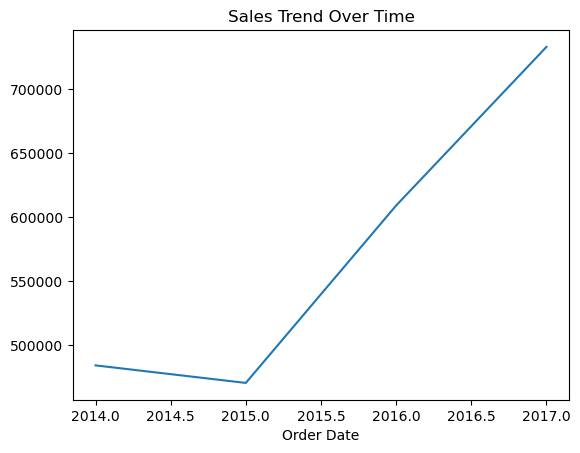

In [21]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df.groupby(df["Order Date"].dt.year)["Sales"].sum().plot(kind="line")
plt.title("Sales Trend Over Time")
plt.show()

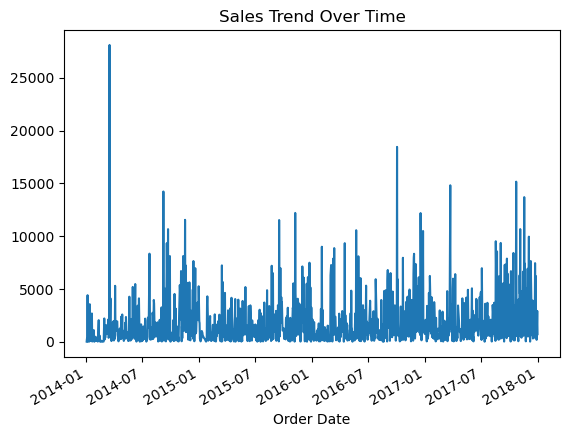

In [22]:
df.groupby(df["Order Date"])["Sales"].sum().plot(kind="line")
plt.title("Sales Trend Over Time")
plt.show()

## 11. Sales Contribution by Customer Segment

This analysis identifies which customer segment contributes the most to total sales.

It helps understand the **target customer group**.

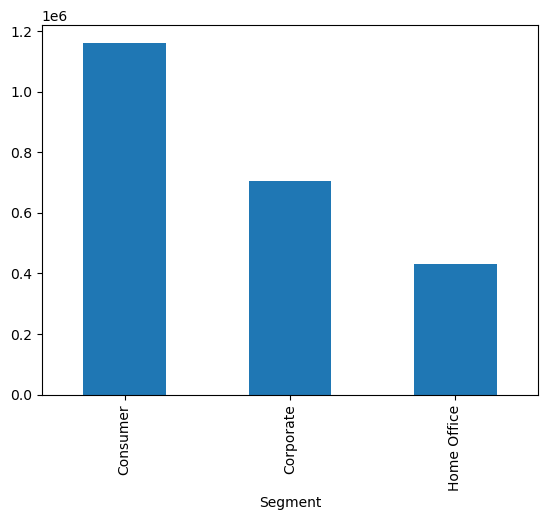

In [23]:
df.groupby("Segment")["Sales"].sum().plot(kind="bar")
plt.show()

## 12. Most Frequently Used Ship Mode

This step determines which shipping method is used most often.

It gives an idea about **customer delivery preferences**.

In [24]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

## 13. Category Sales Across Regions

A pivot table is used to compare sales across both categories and regions.

This allows multi-dimensional analysis in a simple format.

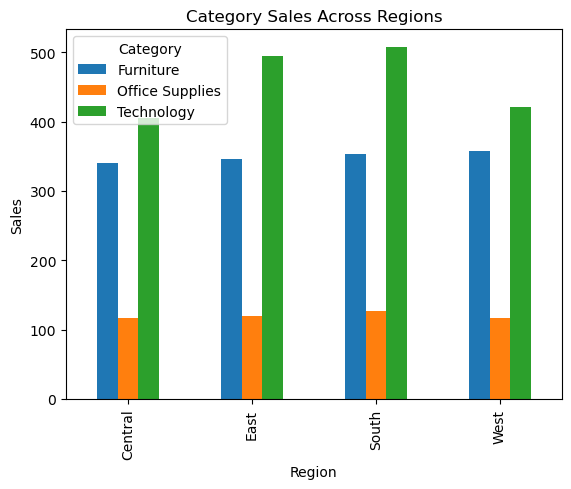

In [25]:
pivot = pd.pivot_table(df, values="Sales", index="Region", columns="Category")

pivot.plot(kind="bar")

plt.title("Category Sales Across Regions")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

## 14. Most Profitable Product

This step identifies the single product that generates the highest profit.

This can help businesses focus on **high-performing products**.

In [26]:
top_product = df.sort_values("Profit", ascending=False)[["Product Name","Profit"]].head(1)

print(top_product)

                               Product Name    Profit
6826  Canon imageCLASS 2200 Advanced Copier  8399.976


In [27]:
product_profit = df.groupby('Product Name')['Profit'].sum()

most_profitable_product = product_profit.idxmax()
max_profit_value = product_profit.max()

print(f"The most profitable product is: {most_profitable_product}")
print(f"Total Profit: ${max_profit_value:,.2f}")

The most profitable product is: Canon imageCLASS 2200 Advanced Copier
Total Profit: $25,199.93


## 15. Business Insights

Based on the analysis performed above, the following insights can be observed:

- Higher **discounts often reduce profit**, even when sales increase.
- Certain regions and cities contribute more to overall **business performance**.
- A small number of products and categories generate a large portion of **total revenue**.

These insights can help in making better decisions related to **pricing, marketing, and inventory management**.